1. ĐANG TẢI DỮ LIỆU...
Kích thước tập Train: (8012, 5)
Kích thước tập Validation: (1000, 5)
Kích thước tập Test: (1000, 5)

Kiểm tra dữ liệu thiếu (Missing Values) trên toàn bộ tập:
uid           0
premise       0
hypothesis    0
label         0
fold          0
dtype: int64

Sample 3 dòng đầu tiên của tập train:


,uid,premise,hypothesis,label,fold
0,uit_Adver_365_3_11_02,Tọa đàm do Tổng cục Du lịch phối hợp với báo đ...,"Đầu tháng 4 có một buổi gặp mặt trao đổi, nói ...",entailment,train
1,uit_Adver_1405_5_11_08,Bệnh viện Đa khoa tỉnh Bắc Ninh xin hội chẩn 2...,"Để giúp các chuyên gia đầu ngành, bệnh viện Đa...",entailment,train
2,uit_Adver_304_2_11_02,"Bộ trưởng Du lịch, tiến sĩ Abdulla Mausoom xác...","3V đại diện cho Visit (Tham quan), Vaccine (Ti...",entailment,train



2. PHÂN TÍCH PHÂN PHỐI NHÃN (LABEL DISTRIBUTION)


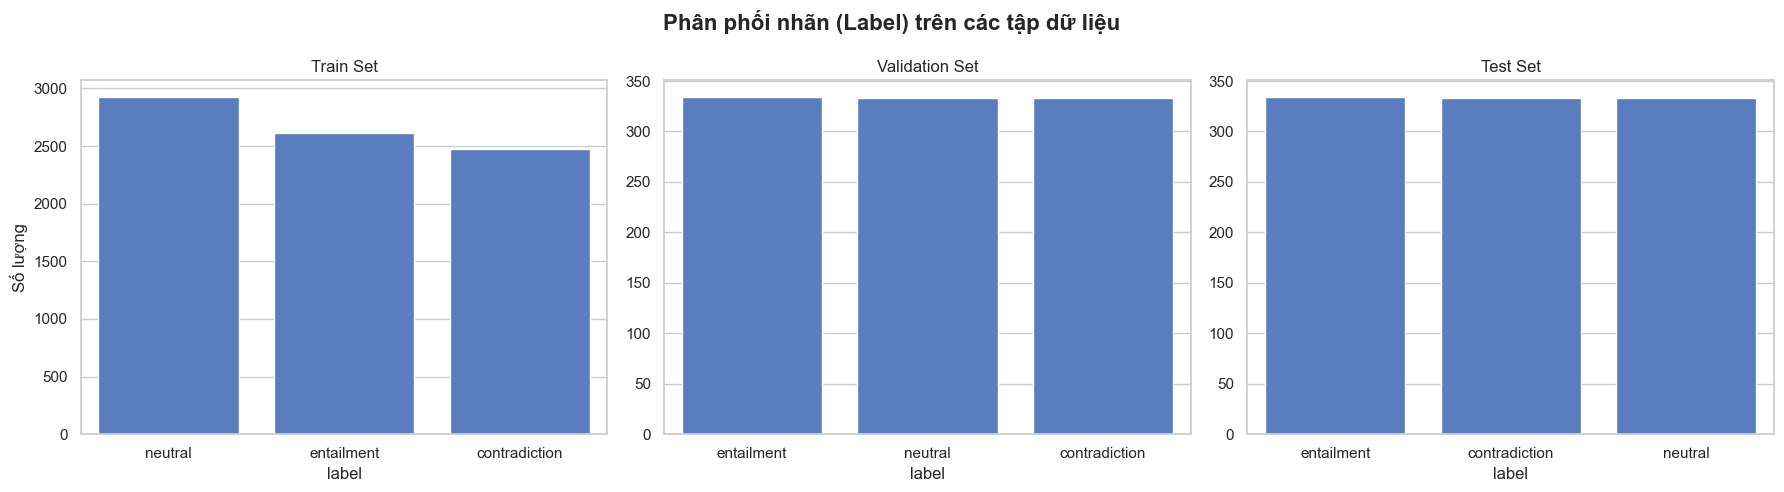


3. PHÂN TÍCH ĐỘ DÀI CÂU (THEO SỐ LƯỢNG ÂM TIẾT)

Thống kê mô tả độ dài câu:


,premise_len,hypothesis_len
count,10012.000000,10012.000000
mean,28.969337,16.813424
std,11.910764,6.810281
min,4.000000,3.000000
25%,21.000000,12.000000
50%,27.000000,16.000000
75%,34.000000,20.000000
max,106.000000,68.000000


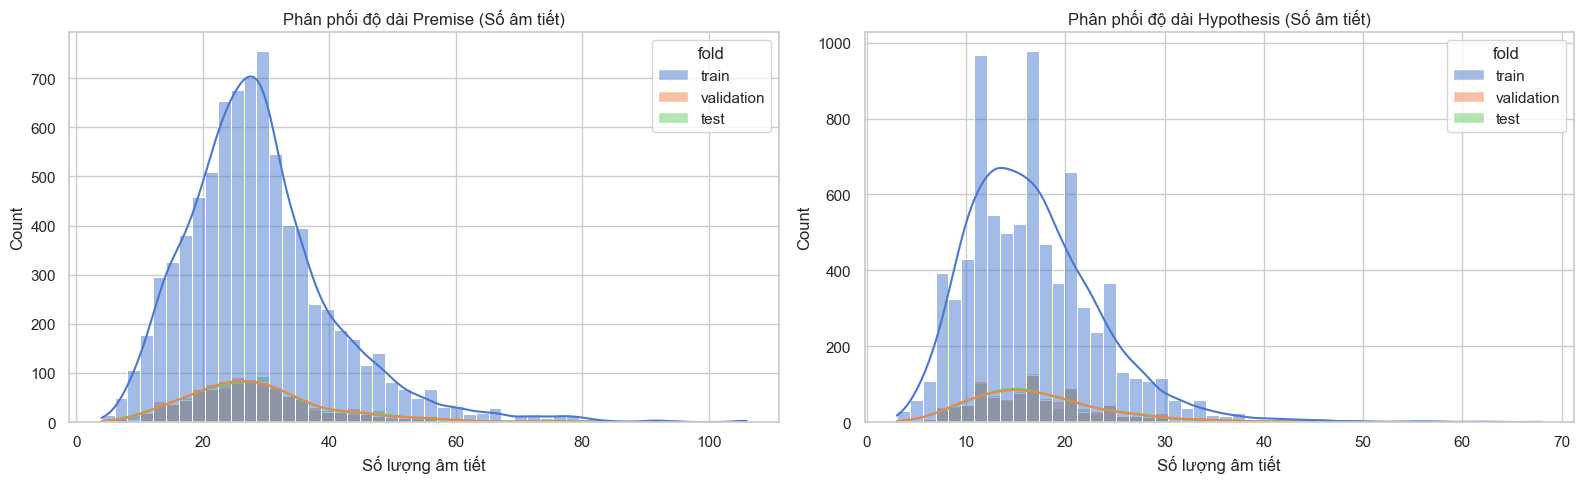


4. PHÂN TÍCH ĐỘ GIAO THOA TỪ VỰNG (LEXICAL OVERLAP) THEO NHÃN


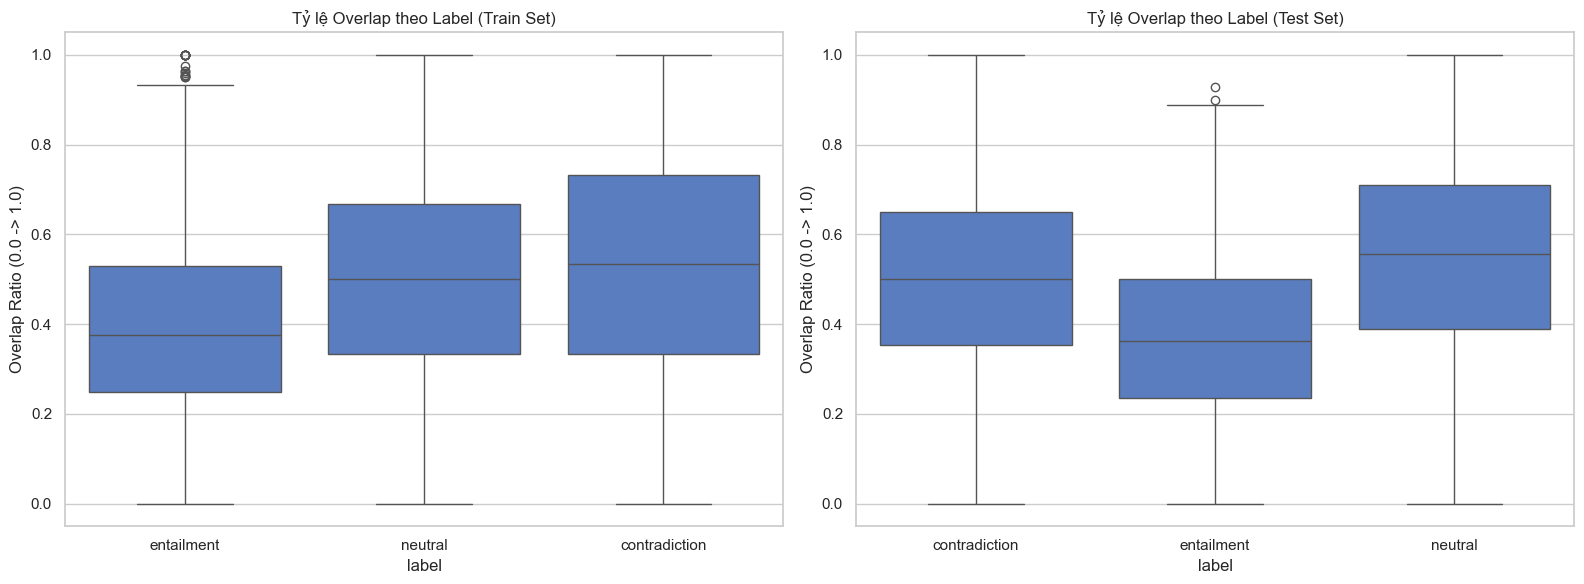


5. TƯƠNG QUAN CÁC ĐẶC TRƯNG VÀ INSIGHT CUỐI


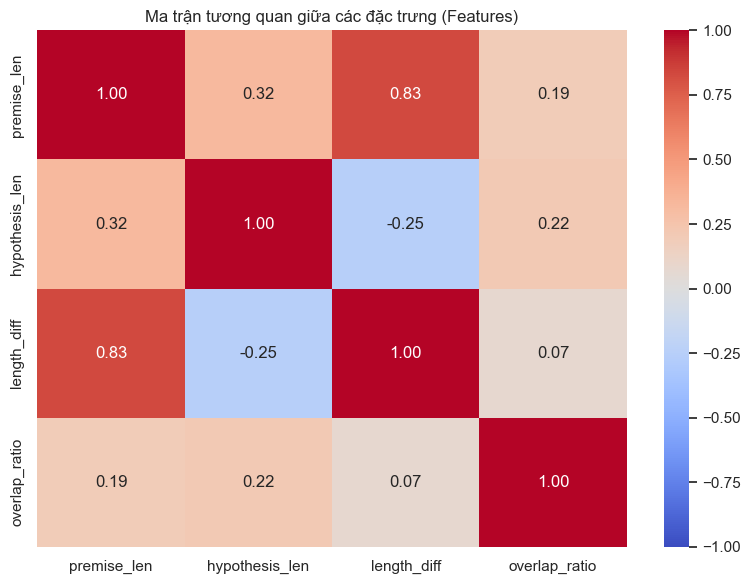


🎯 KẾT LUẬN NHANH DÀNH CHO BÁO CÁO (Dựa vào số liệu sinh ra ở trên):
- CHÚ Ý QUAN TRỌNG: Kiểm tra biểu đồ Boxplot Overlap Ratio ở phần 4.
- Nếu tỷ lệ overlap ở nhãn 'Entailment' rất cao, và 'Contradiction/Neutral' thấp -> Dataset có bias về từ vựng (Word-matching bias).
- Tập Test (ViANLI) thường được sinh ra để phá vỡ bias này. Nếu boxplot ở Test Set (phần 4 bên phải) không có sự khác biệt rõ ràng giữa các nhãn, chứng tỏ các mẫu đối kháng (adversarial) đã được thiết kế cực tốt để lừa mô hình. Đây là insight cốt lõi để bảo vệ ý tưởng dùng MoE giải quyết các ca khó.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tắt các cảnh báo không cần thiết để notebook sạch đẹp
warnings.filterwarnings('ignore')

# Cài đặt style cho biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

# ---------------------------------------------------------
# 1. TẢI VÀ KIỂM TRA DỮ LIỆU CƠ BẢN
# ---------------------------------------------------------
print("="*50)
print("1. ĐANG TẢI DỮ LIỆU...")
print("="*50)

# Cập nhật đường dẫn file csv của bạn nếu nó nằm trong folder khác (ví dụ: 'data/train.csv')
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

# Gán thêm cột fold để dễ phân biệt khi gộp data
train_df['fold'] = 'train'
val_df['fold'] = 'validation'
test_df['fold'] = 'test'

# Gộp tất cả để có cái nhìn tổng quan, nhưng vẫn phân tích chi tiết trên tập train/test
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Validation: {val_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")
print("\nKiểm tra dữ liệu thiếu (Missing Values) trên toàn bộ tập:")
print(all_df.isnull().sum())

# Xóa các dòng có giá trị null (nếu có)
all_df = all_df.dropna().reset_index(drop=True)
train_df = train_df.dropna().reset_index(drop=True)

print("\nSample 3 dòng đầu tiên của tập train:")
display(train_df.head(3))

# ---------------------------------------------------------
# 2. PHÂN PHỐI NHÃN (CLASS IMBALANCE)
# ---------------------------------------------------------
print("\n" + "="*50)
print("2. PHÂN TÍCH PHÂN PHỐI NHÃN (LABEL DISTRIBUTION)")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân phối nhãn (Label) trên các tập dữ liệu', fontsize=16, fontweight='bold')

sns.countplot(data=train_df, x='label', ax=axes[0], order=train_df['label'].value_counts().index)
axes[0].set_title('Train Set')
axes[0].set_ylabel('Số lượng')

sns.countplot(data=val_df, x='label', ax=axes[1], order=val_df['label'].value_counts().index)
axes[1].set_title('Validation Set')
axes[1].set_ylabel('')

sns.countplot(data=test_df, x='label', ax=axes[2], order=test_df['label'].value_counts().index)
axes[2].set_title('Test Set')
axes[2].set_ylabel('')

plt.show()

# ---------------------------------------------------------
# 3. TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)
# ---------------------------------------------------------
# Vì văn bản thô (cách nhau bởi khoảng trắng) nên len(split()) sẽ đếm số lượng ÂM TIẾT (syllables).
# Mặc dù chưa word-segment, đếm âm tiết vẫn phản ánh rất chính xác độ dài và độ phức tạp của câu tiếng Việt.

def calculate_overlap_ratio(row):
    """Tính tỷ lệ phần trăm âm tiết của Hypothesis xuất hiện trong Premise (Lexical Overlap)"""
    premise_tokens = set(str(row['premise']).lower().split())
    hypo_tokens = set(str(row['hypothesis']).lower().split())
    
    if len(hypo_tokens) == 0:
        return 0.0
    
    intersection = premise_tokens.intersection(hypo_tokens)
    return len(intersection) / len(hypo_tokens)

# Tính toán trên tập gộp
all_df['premise_len'] = all_df['premise'].apply(lambda x: len(str(x).split()))
all_df['hypothesis_len'] = all_df['hypothesis'].apply(lambda x: len(str(x).split()))
all_df['length_diff'] = all_df['premise_len'] - all_df['hypothesis_len']
all_df['overlap_ratio'] = all_df.apply(calculate_overlap_ratio, axis=1)

print("\n" + "="*50)
print("3. PHÂN TÍCH ĐỘ DÀI CÂU (THEO SỐ LƯỢNG ÂM TIẾT)")
print("="*50)

print("\nThống kê mô tả độ dài câu:")
display(all_df[['premise_len', 'hypothesis_len']].describe())

# Biểu đồ phân phối độ dài câu
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(data=all_df, x='premise_len', hue='fold', kde=True, bins=50, ax=ax[0], alpha=0.5)
ax[0].set_title('Phân phối độ dài Premise (Số âm tiết)')
ax[0].set_xlabel('Số lượng âm tiết')

sns.histplot(data=all_df, x='hypothesis_len', hue='fold', kde=True, bins=50, ax=ax[1], alpha=0.5)
ax[1].set_title('Phân phối độ dài Hypothesis (Số âm tiết)')
ax[1].set_xlabel('Số lượng âm tiết')

plt.show()

# ---------------------------------------------------------
# 4. PHÂN TÍCH LEXICAL OVERLAP VÀ ĐỐI KHÁNG (ADVERSARIAL INSIGHTS)
# ---------------------------------------------------------
# Lexical overlap là metric cực kỳ quan trọng trong NLI. 
# Mô hình NLI kém thường có xu hướng đoán 'Entailment' nếu overlap cao, và 'Contradiction' nếu overlap thấp.

print("\n" + "="*50)
print("4. PHÂN TÍCH ĐỘ GIAO THOA TỪ VỰNG (LEXICAL OVERLAP) THEO NHÃN")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Boxplot xem phân phối Overlap theo Label
sns.boxplot(data=all_df[all_df['fold'] == 'train'], x='label', y='overlap_ratio', ax=axes[0])
axes[0].set_title('Tỷ lệ Overlap theo Label (Train Set)')
axes[0].set_ylabel('Overlap Ratio (0.0 -> 1.0)')

# Biểu đồ Boxplot xem phân phối Overlap theo Label trên Test
sns.boxplot(data=all_df[all_df['fold'] == 'test'], x='label', y='overlap_ratio', ax=axes[1])
axes[1].set_title('Tỷ lệ Overlap theo Label (Test Set)')
axes[1].set_ylabel('Overlap Ratio (0.0 -> 1.0)')

plt.show()

# ---------------------------------------------------------
# 5. MA TRẬN TƯƠNG QUAN VÀ OUTLIERS
# ---------------------------------------------------------
print("\n" + "="*50)
print("5. TƯƠNG QUAN CÁC ĐẶC TRƯNG VÀ INSIGHT CUỐI")
print("="*50)

# Xem tương quan giữa độ dài câu và tỷ lệ trùng lặp
numeric_cols = ['premise_len', 'hypothesis_len', 'length_diff', 'overlap_ratio']
corr_matrix = all_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Ma trận tương quan giữa các đặc trưng (Features)')
plt.show()

print("\n🎯 KẾT LUẬN NHANH DÀNH CHO BÁO CÁO (Dựa vào số liệu sinh ra ở trên):")
print("- CHÚ Ý QUAN TRỌNG: Kiểm tra biểu đồ Boxplot Overlap Ratio ở phần 4.")
print("- Nếu tỷ lệ overlap ở nhãn 'Entailment' rất cao, và 'Contradiction/Neutral' thấp -> Dataset có bias về từ vựng (Word-matching bias).")
print("- Tập Test (ViANLI) thường được sinh ra để phá vỡ bias này. Nếu boxplot ở Test Set (phần 4 bên phải) không có sự khác biệt rõ ràng giữa các nhãn, chứng tỏ các mẫu đối kháng (adversarial) đã được thiết kế cực tốt để lừa mô hình. Đây là insight cốt lõi để bảo vệ ý tưởng dùng MoE giải quyết các ca khó.")

# Đây là một số kết luận nhanh và quan trọng từ phân tích EDA của bạn, được cấu trúc để bạn có thể đưa vào slide báo cáo của mình cho thầy Hà Anh.

###  **Các Insight Quan Trọng Nhất Cho Báo Cáo**

### **1. Định Kiến Giao Thoa Từ Vựng (Lexical Overlap Bias) - Insight Cốt Lõi**
Đây là phát hiện **quan trọng nhất** để ủng hộ cho nghiên cứu về tính "đối kháng" của nhóm bạn.
* **Train Set:** Cho thấy định kiến heuristics rõ ràng: khi premise và hypothesis trùng lặp nhiều từ, dữ liệu có xu hướng có nhãn là `entailment`. Điều này được minh chứng qua trung vị overlap ratio cao nhất cho `entailment`.
* **Test Set (ViANLI):** Cho thấy một mô hình hoàn toàn **đối lập**. Pattern đã được đảo ngược. Nhãn `entailment` thực sự có trung vị tỷ lệ trùng lặp từ vựng **thấp nhất**. Đây là một dấu hiệu cực kỳ mạnh mẽ về một bộ dữ liệu đối kháng được thiết kế tốt, có thể "lừa" các mô hình chỉ dựa vào các heuristics nông cạn. Nó chứng minh rằng bộ test set thực sự là một thử thách khó khăn.

### **2. Phân Phối Nhãn (Label Distribution)**
* **Train Set:** Có sự mất cân bằng nhẹ về nhãn (class imbalance), với `neutral` là nhãn phổ biến nhất, tiếp theo là `entailment`, và sau đó là `contradiction`. Điều này quan trọng vì mô hình có thể học cách đoán `neutral` nhiều hơn.
* **Validation & Test Set:** Cực kỳ quan trọng, cả hai tập đều được **cân bằng hoàn hảo** trên cả 3 nhãn. Đây là một thiết kế tuyệt vời cho việc đánh giá mô hình, đảm bảo kết quả không bị ảnh hưởng bởi sự mất cân bằng nhãn.

### **3. Phân Phối Độ Dài Câu (Sentence Length Distribution)**
* Như mong đợi trong NLI, premise (câu tiền đề) có xu hướng dài hơn hypothesis (câu giả thuyết). Premise peak ở khoảng 25-30 âm tiết, trong khi hypothesis peak ở khoảng 15 âm tiết.
* Phân phối của cả premise và hypothesis là consistent trên cả 3 tập (train, val, test), cho thấy việc phân tách dữ liệu được thực hiện tốt và mô hình có thể generalization tốt về độ dài.

### **4. Phân Tích Tương Quan (Correlation Analysis)**
* Sự khác biệt về độ dài (`length_diff`) phụ thuộc chính vào độ dài của premise (`premise_len`) với hệ số tương quan 0.83.
* Tỷ lệ giao thoa từ vựng (`overlap_ratio`) không có tương quan mạnh với bất kỳ metric độ dài nào (hệ số max 0.22), cho thấy `overlap_ratio` capture một mối quan hệ phức tạp hơn là chỉ độ dài câu đơn thuần.

**Kết Luận Cho Báo Cáo:** Dựa trên phân tích EDA này, rõ ràng là tập dữ liệu ViANLI có một bộ test set đối kháng cực kỳ chất lượng, đảo ngược các định kiến heuristics phổ biến trong dữ liệu training. Điều này xác nhận rằng hướng đi nghiên cứu về **adversarial robustness** của nhóm là hoàn toàn có cơ sở và có giá trị cao. 
